In [11]:
import os
import sys
import subprocess
from pathlib import Path

import torch


def is_project_root(path):
    path = Path(path)

    return (
        (path / "eytnet").is_dir()
        and (path / "configs").is_dir()
        and (path / "pyproject.toml").is_file()
    )


def find_project_root():
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if is_project_root(path):
            return path

    content = Path("/content")

    if content.is_dir():
        for path in content.iterdir():
            if path.is_dir() and is_project_root(path):
                return path.resolve()

    return None


PROJECT_ROOT = find_project_root()

# Colab'a yalnızca tar yüklenmişse çıkar.
if PROJECT_ROOT is None:
    content = Path("/content")
    archives = sorted(content.glob("*.tar"))

    assert len(archives) == 1, (
        "Proje bulunamadı. Colab'a yalnızca "
        "güncel proje tar dosyasını yükle."
    )

    extract_root = (
        content / "early-fire-detection"
    )

    extract_root.mkdir(
        parents=True,
        exist_ok=True,
    )

    subprocess.run(
        [
            "tar",
            "-xf",
            str(archives[0]),
            "-C",
            str(extract_root),
        ],
        check=True,
    )

    candidates = [
        extract_root,
        *[
            marker.parent
            for marker in extract_root.rglob(
                "pyproject.toml"
            )
        ],
    ]

    PROJECT_ROOT = next(
        path
        for path in candidates
        if is_project_root(path)
    )

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Proje:", PROJECT_ROOT)
print("Cihaz:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Proje: C:\Users\omert\Desktop\fire_guncel_repo
Cihaz: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [12]:
%pip install -q -U kagglehub

Note: you may need to restart the kernel to use updated packages.


c:\Users\omert\Desktop\fire_guncel_repo\.venv\Scripts\python.exe: No module named pip


In [21]:
import kagglehub

EXPECTED_COUNTS = {
    "train": 3900,
    "val": 1300,
    "test": 1300,
}


def valid_dataset(path):
    path = Path(path)

    return all(
        (path / split / "images").is_dir()
        and (path / split / "labels").is_dir()
        for split in EXPECTED_COUNTS
    )


local_data = PROJECT_ROOT / "data"

if valid_dataset(local_data):
    DATA_ROOT = local_data
else:
    downloaded_path = Path(
        kagglehub.dataset_download(
            "pengbo00/home-fire-dataset"
        )
    )

    candidates = [downloaded_path]

    for images_dir in downloaded_path.rglob(
        "images"
    ):
        if images_dir.parent.name == "train":
            candidates.append(
                images_dir.parent.parent
            )

    DATA_ROOT = next(
        path
        for path in candidates
        if valid_dataset(path)
    )

for split, expected in EXPECTED_COUNTS.items():
    image_count = len(
        list(
            (DATA_ROOT / split / "images")
            .glob("*.jpg")
        )
    )

    label_count = len(
        list(
            (DATA_ROOT / split / "labels")
            .glob("*.txt")
        )
    )

    print(
        f"{split:5s} | "
        f"images={image_count} | "
        f"labels={label_count}"
    )

    assert image_count == expected
    assert label_count == expected

print("Dataset:", DATA_ROOT)

train | images=3900 | labels=3900
val   | images=1300 | labels=1300
test  | images=1300 | labels=1300
Dataset: C:\Users\omert\Desktop\fire_guncel_repo\data


In [22]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )
except ImportError:
    print("Yerel ortam: Drive kullanılmadı.")

from eytnet.config import Config
from eytnet.dataset import build_dataloader
from eytnet.model import build_model
from eytnet.postprocess import (
    collect_predictions,
    postprocess,
)
from eytnet.metrics import (
    confidence_sweep,
    evaluate_detections,
    load_ground_truth,
    results_table,
)


RUN_NAME = "eytnet_final_v1_opt_obj01"

run_candidates = [
    (
        PROJECT_ROOT
        / "models"
        / "eytnet"
        / RUN_NAME
    ),
    (
        Path("/content/drive/MyDrive")
        / "EYTNet"
        / "runs"
        / RUN_NAME
    ),
]


FINAL_RUN_DIR = next(
    (
        path.resolve()
        for path in run_candidates
        if (
            (path / "config.json").is_file()
            and
            (
                path
                / "weights"
                / "best.pt"
            ).is_file()
        )
    ),
    None,
)

assert FINAL_RUN_DIR is not None, (
    "Final model bulunamadı, drive'ı bağla veya final run klasörünü models/eytnet altına indir."
    
)

CONFIG_PATH = (
    FINAL_RUN_DIR / "config.json"
)

CHECKPOINT_PATH = (
    FINAL_RUN_DIR
    / "weights"
    / "best.pt"
)

raw = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

raw["data_root"] = str(DATA_ROOT)

cfg = Config(raw)
cfg.data_root = DATA_ROOT
cfg.run_dir = FINAL_RUN_DIR

cfg.batch_size = 4
cfg.num_workers = 0

model = build_model(cfg).to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()

print("Run:", FINAL_RUN_DIR)
print("Best epoch:", checkpoint["epoch"])
print("Validation mAP:", checkpoint["metric"])
print("Parametre:", f"{model.count_parameters():,}")

Yerel ortam: Drive kullanılmadı.
Run: C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01
Best epoch: 60
Validation mAP: 0.4489195162383084
Parametre: 7,208,138


In [23]:
val_loader = build_dataloader(
    cfg,
    "val"
)

val_gt = load_ground_truth(
    cfg.data_root,
    "val",
)

NMS_VALUES = [
    0.30, 0.50, 0.70,
]

CONFIDENCE_VALUES = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.50,
    0.60,
]

selection_rows = []
val_predictions_by_nms = {}

for nms_value in NMS_VALUES:
    print("\nNMS IoU:", nms_value)

    cfg.nms_iou_threshold = nms_value

    predictions = collect_predictions(
        model,
        val_loader,
        cfg,
        device,
        score_threshold=cfg.decode_score_floor,
    )

    val_predictions_by_nms[
        nms_value
    ] = predictions

    map_result = evaluate_detections(
        predictions,
        val_gt,
        cfg.class_names,
        score_threshold=0.25,
        iou_threshold=0.50,
        map5095=False,
    )

    map50 = map_result["overall"]["map50"]

    sweep_rows = confidence_sweep(
        predictions,
        val_gt,
        cfg.class_names,
        thresholds=CONFIDENCE_VALUES,
    )

    for row in sweep_rows:
        selection_rows.append(
            {
                "nms_iou": nms_value,
                "map50": map50,
                **row,
            }
        )

selection_df = pd.DataFrame(
    selection_rows
)

best_row = (
    selection_df
    .sort_values(
        ["f2", "map50", "f1"],
        ascending=False,
    )
    .iloc[0]
)

selected_nms = float(
    best_row["nms_iou"]
)

selected_score = float(
    best_row["threshold"]
)

cfg.nms_iou_threshold = selected_nms

print("Seçilen confidence:", selected_score)
print("Seçilen NMS IoU:", selected_nms)


NMS IoU: 0.3

NMS IoU: 0.5

NMS IoU: 0.7
Seçilen confidence: 0.35
Seçilen NMS IoU: 0.3


,nms_iou,map50,threshold,precision,recall,f1,f2,tp,fp,fn
6,0.3,0.4546,0.35,0.4466,0.5816,0.5052,0.5485,919,1139,661
5,0.3,0.4546,0.30,0.3865,0.6057,0.4719,0.5440,957,1519,623
16,0.5,0.4489,0.35,0.3865,0.6000,0.4701,0.5403,948,1505,632
7,0.3,0.4546,0.40,0.5003,0.5506,0.5243,0.5398,870,869,710
4,0.3,0.4546,0.25,0.3346,0.6354,0.4383,0.5386,1004,1997,576
17,0.5,0.4489,0.40,0.4347,0.5665,0.4919,0.5341,895,1164,685
15,0.5,0.4489,0.30,0.3285,0.6278,0.4313,0.5310,992,2028,588
14,0.5,0.4489,0.25,0.2801,0.6620,0.3936,0.5201,1046,2689,534
3,0.3,0.4546,0.20,0.2770,0.6614,0.3905,0.5177,1045,2727,535
8,0.3,0.4546,0.50,0.5964,0.4975,0.5424,0.5145,786,532,794


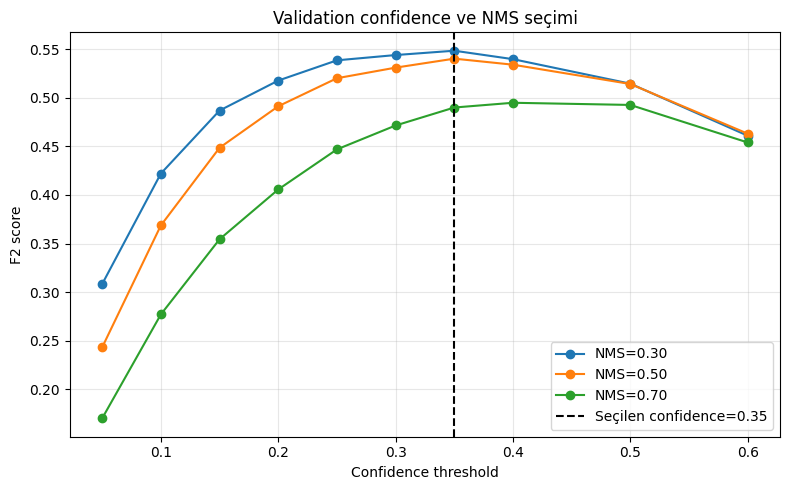

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.6767,0.3683,0.4555,0.7809,0.5754,0.6833,752,899,211
smoke,0.2324,0.0812,0.4103,0.2707,0.3262,0.2904,167,240,450
TOPLAM,0.4546,0.2247,0.4466,0.5816,0.5052,0.5485,919,1139,661


In [24]:
display(
    selection_df
    .sort_values(
        ["f2", "map50"],
        ascending=False,
    )
    .head(15)
    .round(4)
)

plt.figure(figsize=(8, 5))

for nms_value in NMS_VALUES:
    current = selection_df[
        selection_df["nms_iou"] == nms_value
    ]

    plt.plot(
        current["threshold"],
        current["f2"],
        marker="o",
        label=f"NMS={nms_value:.2f}",
    )

plt.axvline(
    selected_score,
    color="black",
    linestyle="--",
    label=(
        f"Seçilen confidence="
        f"{selected_score:.2f}"
    ),
)


plt.xlabel("Confidence threshold")
plt.ylabel("F2 score")
plt.title("Validation confidence ve NMS seçimi")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

val_predictions = (
    val_predictions_by_nms[selected_nms]
)

val_results = evaluate_detections(
    val_predictions,
    val_gt,
    cfg.class_names,
    score_threshold=selected_score,
    iou_threshold=0.50,
    map5095=True,
)

display(results_table(val_results))

,ap50,ap5095,precision,recall,f1,f2,tp,fp,fn
sinif,,,,,,,,,
fire,0.5569,0.2724,0.4280,0.6656,0.5209,0.5990,597,798,300
smoke,0.1783,0.0623,0.3662,0.2046,0.2626,0.2245,141,244,548
TOPLAM,0.3676,0.1673,0.4146,0.4653,0.4385,0.4542,738,1042,848


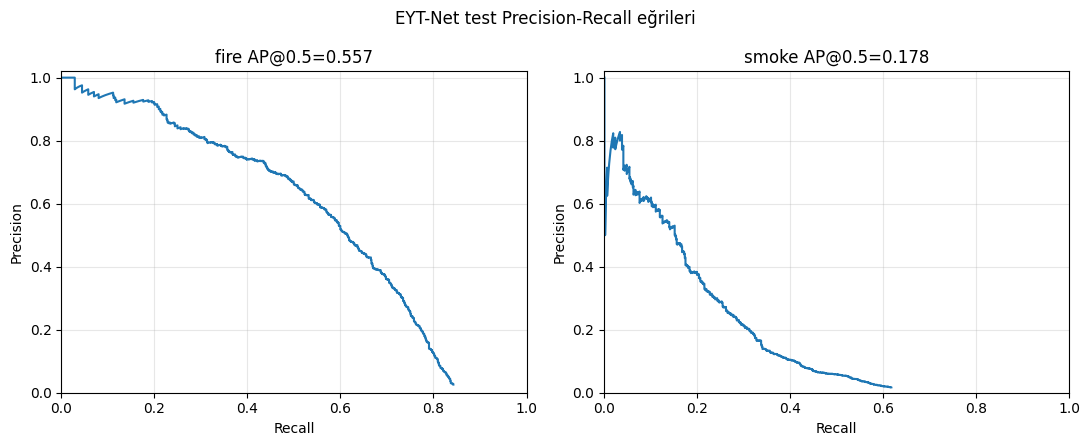

In [25]:
test_loader = build_dataloader(
    cfg,
    "test",
)

test_gt = load_ground_truth(
    cfg.data_root,
    "test",
)

test_predictions = collect_predictions(
    model,
    test_loader,
    cfg,
    device,
    score_threshold=cfg.decode_score_floor,
)

test_results = evaluate_detections(
    test_predictions,
    test_gt,
    cfg.class_names,
    score_threshold=selected_score,
    iou_threshold=0.50,
    map5095=True,
)

display(results_table(test_results))

fig, axes = plt.subplots(
    1,
    len(cfg.class_names),
    figsize=(11, 4.5),
)

for axis, class_name in zip(
    axes,
    cfg.class_names,
):
    recall, precision = (
        test_results["curves"][class_name]
    )

    ap50 = test_results[
        "per_class"
    ][class_name]["ap50"]

    axis.plot(recall, precision)
    axis.set_title(
        f"{class_name} AP@0.5={ap50:.3f}"
    )
    axis.set_xlabel("Recall")
    axis.set_ylabel("Precision")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.grid(alpha=0.3)

plt.suptitle(
    "EYT-Net test Precision-Recall eğrileri"
)
plt.tight_layout()

PR_FIGURE_PATH = (
    FINAL_RUN_DIR / "test_pr_curves.png"
)

plt.savefig(
    PR_FIGURE_PATH,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [27]:
def synchronize():
    if device.type =="cuda":
        torch.cuda.synchronize()

warmup_images, _, _ = next(
    iter(test_loader)

)

warmup_images = warmup_images.to(device)

with torch.no_grad():
    for _ in range(3):
        outputs = model(warmup_images)

        postprocess(
            outputs,
            cfg,
            score_threshold=selected_score,
        )

synchronize()

total_seconds = 0.0
total_images = 0

with torch.no_grad():
    for images, _, _ in test_loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        synchronize()
        started = time.perf_counter()

        outputs = model(images)

        postprocess(
            outputs,
            cfg,
            score_threshold=selected_score,
        )

        synchronize()

        total_seconds += (
            time.perf_counter() - started
        )

        total_images += len(images)

inference_ms = (
    total_seconds
    / total_images
    * 1000
)

fps = total_images / total_seconds

print(
    "Model + postprocess:",
    round(inference_ms, 2),
    "ms/görüntü",
)

print("FPS:", round(fps, 2))


def json_ready(value):
    if isinstance(value, dict):
        return {
            key: json_ready(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            json_ready(item)
            for item in value
        ]

    if isinstance(value, np.generic):
        value = value.item()

    if (
        isinstance(value, float)
        and np.isnan(value)
    ):
        return None

    return value


np.savez_compressed(
    FINAL_RUN_DIR / "test_predictions.npz",
    **test_predictions,
)

selection_df.to_csv(
    FINAL_RUN_DIR / "threshold_selection.csv",
    index=False,
)

result_payload = {
    "model": "EYT-Net",
    "checkpoint": str(CHECKPOINT_PATH),
    "score_threshold": selected_score,
    "nms_iou_threshold": selected_nms,
    "inference_ms_per_image": inference_ms,
    "fps": fps,
    "per_class": test_results["per_class"],
    "overall": test_results["overall"],
}

(
    FINAL_RUN_DIR / "test_results.json"
).write_text(
    json.dumps(
        json_ready(result_payload),
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print("Kaydedildi:")
print(FINAL_RUN_DIR / "test_predictions.npz")
print(FINAL_RUN_DIR / "test_results.json")
print(FINAL_RUN_DIR / "threshold_selection.csv")
print(PR_FIGURE_PATH)

Model + postprocess: 15.93 ms/görüntü
FPS: 62.78
Kaydedildi:
C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01\test_predictions.npz
C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01\test_results.json
C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01\threshold_selection.csv
C:\Users\omert\Desktop\fire_guncel_repo\models\eytnet\eytnet_final_v1_opt_obj01\test_pr_curves.png
